In [23]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import warnings




#Read the Data 


data = pd.read_excel(r"C:\Users\Eric\OneDrive - McGill University\Desktop\Python\python_training\Sales.xlsx")


In [24]:
# Inspect the first few rows of the DataFrame

data.head()
data.head()

data.info()
data.info()

data.isna().sum()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 508 entries, 0 to 507
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order_ID         508 non-null    object 
 1   Order_Date       468 non-null    object 
 2   Category         508 non-null    object 
 3   Region           508 non-null    object 
 4   Units_Sold       489 non-null    object 
 5   Unit_Price       478 non-null    object 
 6   Customer_Age     482 non-null    float64
 7   Customer_Rating  478 non-null    float64
dtypes: float64(2), object(6)
memory usage: 31.9+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 508 entries, 0 to 507
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order_ID         508 non-null    object 
 1   Order_Date       468 non-null    object 
 2   Category         508 non-null    object 
 3   Region           508 non-null    object 
 4 

Order_ID            0
Order_Date         40
Category            0
Region              0
Units_Sold         19
Unit_Price         30
Customer_Age       26
Customer_Rating    30
dtype: int64

In [25]:
# Data Quality check 

for columns in data.columns:
    missing_pct = data[columns].isnull().mean()*100
    if missing_pct > 0 :
        print(f"Column '{columns}' is missing {missing_pct:.1f}% of data")

# Check which rows have missing values

data[data.isnull().any(axis =1)]


#find duplicate 
data.duplicated().sum()

# Filter DataFrame to inspect duplicate rows
duplicates_data = data[data.duplicated(keep= False)]
print(duplicates_data)




Column 'Order_Date' is missing 7.9% of data
Column 'Units_Sold' is missing 3.7% of data
Column 'Unit_Price' is missing 5.9% of data
Column 'Customer_Age' is missing 5.1% of data
Column 'Customer_Rating' is missing 5.9% of data
     Order_ID  Order_Date        Category   Region Units_Sold Unit_Price  \
10   ORD-1010  2023-02-14     Electronics    North          7     $51.82   
11   ORD-1011  2023-10-30  Home & Kitchen     West         11      35.32   
12   ORD-1012  2023-08-05     Electronics       N.         11        NaN   
13   ORD-1013  01/17/2023  Home & Kitchen     EAST          8     274.91   
14   ORD-1014  2023-01-16  Home & Kitchen    North          5     322.34   
15   ORD-1015  2023-02-17  Home & Kitchen  Central          4     365.78   
16   ORD-1016  2023-04-22           Books    South          8     488.17   
17   ORD-1017  2023-04-30        Clothing       N.          8     262.99   
500  ORD-1010  2023-02-14     Electronics    North          7     $51.82   
501  ORD-1011

In [26]:
#STEP 2 : DATA CLEANING 
#-Inconsistent Date Formats: Mixed YYYY-MM-DD and MM/DD/YYYY strings.
#Inconsistent Categories & Regions: Extra whitespace, random lowercasing, and typos (e.g., 'Electrronics').
#Data Type Violations: Currency symbols ($) formatted as text, numbers written as words (e.g., 'Five').
#Missing Data (NaNs): Null entries scattered across dates, prices, units sold, ratings, and customer ages.
#Outliers & Bad Data: Negative customer ages, impossible ages (e.g., 150), and extreme price outliers.
# Outliers & Bad Data: Negative customer ages, impossible ages (e.g., 150), and extreme price outliers.
#Duplicate Rows: Contains duplicate records to identify and clean.
#




In [27]:
#-Inconsistent Date Formats: Mixed YYYY-MM-DD and MM/DD/YYYY strings.

def clean_data(data):
     # Convert dates to datetime
    data["Order_Date"] = pd.to_datetime(data["Order_Date"], errors= "coerce")
    return data 
# Pass 'data' into the function
data= clean_data(data)
# Check the updated column data type and first few rows
print(data["Order_Date"].head())

    




0   2023-11-24
1   2023-02-27
2   2023-01-13
3   2023-05-21
4          NaT
Name: Order_Date, dtype: datetime64[ns]


In [28]:
#Inconsistent Categories & Regions: Extra whitespace, random lowercasing, and typos (e.g., 'Electrronics').

# 1. Clean Category Column
# Trim extra spaces and convert to Title Case
data['Category'] = data['Category'].astype(str).str.strip().str.title()
# Fix specific typos

Category_mapping = { 
    'Electrronics' : 'Electronics',
    'Nan' : 'None'

}
data['Category'] = data['Category'].replace(Category_mapping)

# 2. Clean Region Column
# Trim extra spaces and convert to Title Case
data['Region'] = data['Region'].astype(str).str.strip().str.title()

# Fix abbreviations and casing inconsistencies
region_mapping = {
    'N.': 'North',
    'Nan': None,
    'EAST': 'east',
    'CENTRAL':'Central',
    'SOUTH' : 'South'
}
data['Region'] = data['Region'].replace(region_mapping)

In [29]:
#Data Type Violations: Currency symbols ($) formatted as text, numbers written as words (e.g., 'Five').
#Convert value to string

data['Unit_Price'] =( data['Unit_Price'].astype(str).replace('$', '', regex= False ).str.strip()
)
data['Unit_Price'] = pd.to_numeric(data['Unit_Price'], errors='coerce')

#FOR column 'Units_Sold':

word_to_num= {
'one': 1, 'two': 2, 'three': 3, 'four': 4, 'five': 5,
    'six': 6, 'seven': 7, 'eight': 8, 'nine': 9, 'ten': 10
}

# Normalize string values to lowercase before mapping
cleaned_units= data['Units_Sold'].astype(str).str.strip().str.lower()
data['Units_Sold']= cleaned_units.replace(word_to_num)

# Convert to numeric float/integer
data['Units_Sold'] = pd.to_numeric(data['Units_Sold'], errors='coerce')



In [30]:
#Missing Data (NaNs): Null entries scattered across dates, prices, units sold, ratings, and customer ages.

def missing_data(data):

 try:
  
 #Copy the data 
    Cleaned_data =data.copy()

   #Handling missing for Date 
    if 'Order_Date' in Cleaned_data.columns:
     Cleaned_data['Order_Date'] = Cleaned_data['Order_Date'].fillna('Unknown')

    if 'Units_Sold' in Cleaned_data.columns:
      Cleaned_data['Units_Sold'] = Cleaned_data['Units_Sold'].fillna('Unknown')

    if 'Unit_Price' in Cleaned_data.columns:
      Cleaned_data['Unit_Price'] = Cleaned_data['Unit_Price'].fillna('Unknown')

    if 'Customer_Rating' in Cleaned_data.columns:  
      Cleaned_data['Customer_Rating'] = Cleaned_data['Customer_Rating'].fillna('Unknown')

    
    if 'Customer_Age' in Cleaned_data.columns:  
      Cleaned_data['Customer_Age'] = Cleaned_data['Customer_Age'].fillna('Unknown')


   
    return Cleaned_data

 except Exception as e:
        print(f"Error during missing data handling: {e}")
        return data

new_data = missing_data(data)
   

In [31]:
# Identify the duplicate data  and Clean the Data 


def remove_duplicate(new_data):

    #Count the number of the duplicated data 
    data_count = new_data.duplicated().sum()
    print(f"the number of duplicated rows is : {data_count} duplicated rows ")

    #REMOVE DUPLICATE ROWS:

    drop_data = new_data.drop_duplicates(keep= 'first')

    #RESET DATAFRAME INDEX

    reset_data = new_data.reset_index(drop=True)

    return new_data

new_version_data = remove_duplicate(new_data)


the number of duplicated rows is : 8 duplicated rows 


In [32]:
# Analysis Question 
# Revenue Baseline: What is the total revenue, total units sold, and overall average order value (AOV) across the entire cleaned dataset?

new_version_data["Unit_Price"] = pd.to_numeric(new_version_data["Unit_Price"], errors="coerce")
new_version_data["Units_Sold"] = pd.to_numeric(new_version_data["Units_Sold"], errors="coerce")
#Calculate 

new_version_data['Total Revenue'] = new_version_data['Unit_Price']* new_version_data['Units_Sold']
total_rev= new_version_data['Total Revenue'].sum()
print (f"the total revenue is {total_rev} CAD")

#Total Units Sold

Sold_Units = new_version_data['Units_Sold'].count()
print(f"The total Units Sold is {Sold_Units}")

#average order value (AOV) across the entire cleaned dataset

aov = total_rev/Sold_Units
print(f"The Average Order Value is {aov}")



the total revenue is 757621.9199999999 CAD
The total Units Sold is 489
The Average Order Value is 1549.329079754601


In [33]:
#Q2. Category Performance: Which product category generates the highest total revenue, and which has the highest average unit price?

# product category generates the highest total revenue
high_total_revenue = new_version_data.groupby('Category')['Total Revenue'].sum().idxmax()
print(f"The product category that generates the highest total revenue is: {high_total_revenue}")

#the highest average unit price
High_avg_unit_price = new_version_data.groupby('Category')['Unit_Price'].sum().idxmax()
print(f"The product category that has the highest Unit_Price is: {High_avg_unit_price}")

The product category that generates the highest total revenue is: Home & Kitchen
The product category that has the highest Unit_Price is: Home & Kitchen


In [34]:
# Q3. Regional Distribution: What is the total revenue breakdown across regions (North, South, East, West, Central)? Which region accounts for the largest share of overall volume?

revenue_breakdown = new_version_data.groupby('Region')['Total Revenue'].sum()
print(f"Total Revenue Breakdown by Region \n : {revenue_breakdown}")

#Which region accounts for the largest share of overall volume
largest_volume = new_version_data.groupby('Region')['Units_Sold'].sum().idxmax()
print(f"the region that has the largest share of overall volume is  : \n {largest_volume}")


Total Revenue Breakdown by Region 
 : Region
Central    155760.27
East       169789.60
North      124996.52
South      160317.85
West       146757.68
Name: Total Revenue, dtype: float64
the region that has the largest share of overall volume is  : 
 East


In [35]:
#Customer Ratings Overview: What is the average customer rating per product category? 

#Convert the 'Customer_Rating' column to numeric, coercing errors 
Rating = pd.to_numeric(new_version_data['Customer_Rating'], errors='coerce')   
#Calcate the average customer rating per product category
Avg_Customer_Rating = Rating.groupby(new_version_data['Category']).mean()
print(f"The Average Customer Rating Per Product is  \n : {Avg_Customer_Rating}")

#Are customers generally more satisfied with lower-priced or higher-priced products?
#Convert Unit_Price to numeric, coercing errors
Price = pd.to_numeric(new_version_data['Unit_Price'], errors='coerce')  
#calculate the correlation between Unit_Price and Customer_Rating
Price_Correlation = Price.corr(Rating)
print(f"The correlation between Unit_Price and Customer_Rating is: {Price_Correlation}")

if Price_Correlation > 0 :
    print(f"Customers are generally more satisfied with HIGHER-priced products")
if Price_Correlation < 0 :
    print(f"Customers are generally more satisfied with LOWER-priced products")
else :
    print(f"Price has no noticeable impact on satisfaction")    

The Average Customer Rating Per Product is  
 : Category
Books             3.320000
Clothing          3.329268
Electronics       3.370000
Home & Kitchen    3.466667
Sports            3.318681
Name: Customer_Rating, dtype: float64
The correlation between Unit_Price and Customer_Rating is: 0.04863326234109804
Customers are generally more satisfied with HIGHER-priced products
Price has no noticeable impact on satisfaction


In [36]:
# Age Demographics: What is the median customer age across the dataset, and how are customers distributed across age brackets (e.g., <25, 25-40, 41-60, 60+)
#Convert the 'Customer_Age' column to numeric, coercing errors
new_version_data['Customer_Age'] = pd.to_numeric(new_version_data['Customer_Age'], errors='coerce')

Median_Age = new_version_data['Customer_Age'].median()
print(f"The median customer age across the dataset is: {Median_Age}")

# how are customers distributed across age brackets
Age_data= new_version_data['Customer_Age'].copy()
#define age group 
bins = [ 0 , 25 , 40 , 60, 100]
Label = ['<25', '25-40', '41-60','60 +']

# Create the Age_Group column using pd.cut
new_version_data['Category_Age']= pd.cut(Age_data,bins=bins, labels=Label, right= True)
#Print 
print(f"The distribution of customers across age brackets is: \n {new_version_data['Category_Age'].value_counts()}")



The median customer age across the dataset is: 45.0
The distribution of customers across age brackets is: 
 Category_Age
41-60    194
25-40    127
60 +      91
<25       67
Name: count, dtype: int64


 the correlation between the Unit Price and and Units Sold is : -0.011940581604069495
there is a negative correlation between the Unit Price and Units Sold,  meaning that selling higher unit quantities comes from lower unit prices


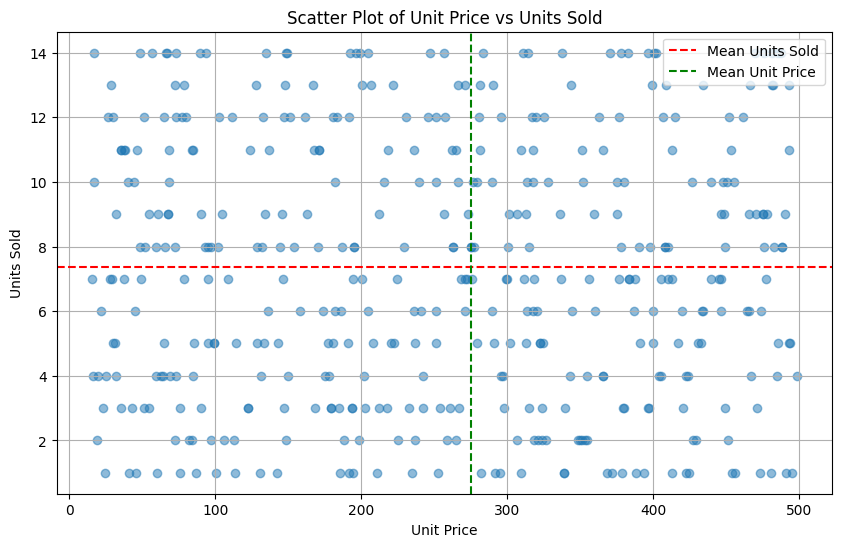

In [38]:
#Part 2: Diagnostic & Comparative Analysis

#Q6. Region vs. Category Matrix: Which specific product category is the top seller in each region?

new_version_data.pivot_table( index='Region', columns = 'Category', values= 'Units_Sold', aggfunc='sum')

#Q7. Volume vs. Price Relationship: Does selling higher unit quantities come from lower unit prices? 
# Is there a noticeable correlation between Unit_Price and Units_Sold?

volume_relationship = new_version_data[['Unit_Price', 'Units_Sold']].corr()
print(f" the correlation between the Unit Price and and Units Sold is : {volume_relationship.loc['Unit_Price','Units_Sold']}")

if volume_relationship.loc['Unit_Price','Units_Sold'] > 0 :
    print(
        "There is a positive correlation between Unit_Price and Units_Sold, "
        "meaning that selling higher unit quantities comes from higher unit prices."
    )
if volume_relationship.loc['Unit_Price','Units_Sold'] < 0 :
    print(f"there is a negative correlation between the Unit Price and Units Sold, "
         " meaning that selling higher unit quantities comes from lower unit prices"
          )   




#DRAW THE SCATTER PLOT

figsize= (10,6)
fig,ax = plt.subplots(figsize=figsize)
ax.scatter(new_version_data['Unit_Price'], new_version_data['Units_Sold'], alpha
=0.5)
ax.set_title('Scatter Plot of Unit Price vs Units Sold')
ax.set_xlabel('Unit Price')
ax.set_ylabel('Units Sold') 
ax.grid(True)
ax.axhline(y=new_version_data['Units_Sold'].mean(), color='r', linestyle='--', label='Mean Units Sold')
ax.axvline(x=new_version_data['Unit_Price'].mean(), color='g', linestyle='--', label='Mean Unit Price')
ax.legend() 
 

